In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns



regions = ["H1", "H2", "L1", "L2", "L3"]
seq_regions = ["SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]
cf_regions = ["CF_H1", "CF_H2", "CF_L1", "CF_L2", "CF_L3"]
len_regions = ["LEN_H1", "LEN_H2", "LEN_L1", "LEN_L2", "LEN_L3"]
meta_cols = ["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species"]


ab_ag_scalop = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset = seq_regions)
    .dropna(subset = cf_regions)
    .drop_duplicates(subset = seq_regions) 
)

antigen_counts = ab_ag_scalop["antigen_name"].value_counts() # Tabelle aus antigen_names und ihren Häufigkeiten in der Spalte antigen_name
ab_ag_scalop = ab_ag_scalop[ab_ag_scalop["antigen_name"].isin(antigen_counts[antigen_counts >= 10].index)]# Behält nur Zeilen, deren antigen_name mindestens 5-mal vorkommt

In [26]:
for cf_region, seq_region in zip(cf_regions, seq_regions):    
    print(f"Cluster in {cf_region}: {sorted(ab_ag_scalop[cf_region].astype(str).unique().tolist())}")
    print(f"Längen in {cf_region}: {sorted(ab_ag_scalop[seq_region].astype(str).map(len).unique().tolist())}\n")

Cluster in CF_H1: ['H1-7-A', 'H1-7-B', 'H1-7-C', 'H1-7-D', 'H1-8-A', 'H1-8-B', 'H1-9-A', 'H1-9-B', 'nan']
Längen in CF_H1: [4, 5, 6, 7, 8, 9, 13, 16]

Cluster in CF_H2: ['H2-5-A', 'H2-6-A', 'H2-6-B', 'H2-6-C', 'H2-6-D', 'H2-6-E', 'H2-8-A', 'nan']
Längen in CF_H2: [4, 5, 6, 7, 8, 10, 11, 16]

Cluster in CF_L1: ['L1-10-A', 'L1-11-A', 'L1-11-B', 'L1-12-A', 'L1-12-B', 'L1-12-C', 'L1-13-A', 'L1-13-B', 'L1-13-C', 'L1-14-A', 'L1-14-B', 'L1-14-C', 'L1-15-A', 'L1-16,17-A', 'nan']
Längen in CF_L1: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Cluster in CF_L2: ['L2-7-A', 'nan']
Längen in CF_L2: [7, 11, 12]

Cluster in CF_L3: ['L3-10,11-A', 'L3-10-A', 'L3-10-B', 'L3-11-A', 'L3-5-A', 'L3-8-A', 'L3-9,10-A', 'L3-9-A', 'nan']
Längen in CF_L3: [5, 6, 8, 9, 10, 11, 12, 13]



In [27]:
# Before clustering, Scalop groups CDR-sequences by length. However, some sequences in our dataset have a length, for which Scalop cannot assign a cluster.
# These sequences are unusually long or short (e.g. für CDR-H1: lengths 4, 5, 6, 12, 13, 16 do not yield any clusters, lenghts 7 and 8 do yield clusters) and are rare in our dataset as they are outliers.
# Proportion tests will be conducted only on length-groups, for which Scalop can assign clusters. Sequences in those length-groups, which were not assigned a cluster (nan) will be considered as cluster "others"
# in their respective length-group. Length groups, that did not yield any clusters will be discarded and not analyzed further.

In [ ]:
# valid_lens kann ich mir sparen mit .dropna(cf_regions)

regions_dict = {}

for region, seq_region, cf_region, len_region in zip(regions, seq_regions, cf_regions, len_regions):

    # DataFrame für jede Region, der alle Sequenzen nach Längengruppe und Cluster sortiert

    df = ab_ag_scalop[meta_cols + [seq_region, cf_region]].copy() # Erstellt eue Kopie von df für jede Region, damit nicht jede Region den originalen df überschreibt
    df[len_region] = df[seq_region].str.len() # Neue Spalte für die Sequenzlänge
    df[cf_region] = df[cf_region].fillna("others") # Ersetzt fehlende Cluster durch "others" 
    df = df.sort_values(by=[len_region, cf_region]) # Sortiert nach Länge und Cluster


    # DataFrame für jede Region aufteilen in DataFrames für jede Längengruppe und filtern nach Längengruppen mit gültigen Cluster-Zuordnungen durch Scalop

    valid_lens = (
    df[df[cf_region] != "others"] # nur Zeilen, in denen es gültige Cluster-Zuordnungen durch Scalop gibt
    [len_region].unique().tolist() # Sequenzlängen, die in den gültigen Zeilen vorkommen, aus der Spalte zur Sequenzlänge extrahieren
    )

    len_groups_dict = {} # Dictionary initialisieren für die DataFrames aller gültigen Längen-Gruppen
    for len_group in valid_lens:
        df_len = df[df[len_region] == len_group] # Zeilen aus dem großen DataFrame filtern, die zur gleichen, gültigen Längengruppe gehören
        len_groups_dict[len_group] = df_len # gefilterten DataFrame in das Dictionary aufnehmen

    regions_dict[region] = len_groups_dict # Dictionary für DataFrames derselben Region in ein äußeres Dictionary anlegen

Using the sorted tables that show which antigen an antibody binds and which canical clusters its CDR sequences belongt to, a proportion test was conducted to analyze the correlation between the canonical cluster a CDR region belongs to and the antigen that is bound by the respective antibody. Since both variables "canonical cluster" and "antigen" are categorial, a proportion test was conducted. As shown in data_exploration, the antigens in our dataset are heavily skewed, with some antigens bound by only antibody (e.g. alpha-bungaratoxin) and other antigens bound by over 200 antibodies (e.g.spike glycoprotein s1). Conventional proportion tests, such as Chi-squared Test of Independence, work for distributions with outliers that are highly overrepresented in the dataset. However, Chi-squared is based on contingency tables and assumes, that there are no counts lower than 5. Even after discarding antigens which are represented less than 10 times in our dataset, we could not avoid counts lower than 5 in the contingency table. Therefore, the theoretical Chi-squared distributions used to determine significance ob observed Chi-squared values are no longer valid for our dataset. In order to use Chi-squared Test of Independence, we had to approximate Chi-squared distributions using permutation tests. 1,000 Chi-squared values were generated using permutations of the antigen distribution in our dataset. p-values were calculated by comparing oberserved Chi-squared values with the approximated distribution.

Our results show, that in some lenth groups there seems to be a significant effect, whereas most length groups yield no significant effect. Promising length groups for further analysis are ... . Some length groups contain only one cluster. In this case, no proportion test could be conducted.

Lin JJ, Chang CH, Pal N. A revisit to contingency table and tests of independence: bootstrap is preferred to Chi-square approximations as well as Fisher's exact test. J Biopharm Stat. 2015;25(3):438-58. doi: 10.1080/10543406.2014.920851. PMID: 24905809.

In [29]:
def normalize_contingency(contingency):
    """Normiere eine Kontingenztabelle zeilenweise (relative Häufigkeiten pro Cluster)."""
    row_sums = contingency.sum(axis=1)
    normalized = contingency.div(row_sums.where(row_sums != 0, other=1), axis=0)
    normalized.loc[row_sums == 0, :] = 0
    return normalized

In [30]:
def permutation_test(contingency, n_permutations, bootstrap_iterations, seed=None):
    np.random.seed(seed)
    # Setzt Startpunkt der Generation von Zufallszahlen fest, damit Ergebnisse bei Wiederholung vergleichbar sind

    # Beobachtete Teststatistik
    chi2_obs, _, dof, _ = chi2_contingency(contingency)
    # chi2_contingency führt einen klassischen Chi2-Unabhängigkeitstest basierend auf der beobachteten Kontingenztabelle durch, d.h:
    # - berechnet beobachtete Teststatistik Chi2 = (Oij - Eij)^2/Eij
    # - vergleicht beobachteten Chi2-Wert mit theoretischer Chi2-Verteilung und gibt p-Wert (entfällt, weil Annahme der theoretischen Chi2-Verteilung ungültig)
    # - gibt dof der Kontingenztabelle bei festen Randwerten aus (hier nicht benötigt)
    # - gibt theoretische Kontingenztabelle mit den Erwartungswerten Eij = ((Summe der Zeile i) * (Summe der Spalte j))/Gesamtsumme aus (hier nicht benötigt)

    # Einträge der Kontingenztabelle als Liste
    data = contingency.stack().reset_index().values.tolist()
    # .stack(): Erstellt aus der Kontingenztabelle eine pd.Series (Index: (Cluster i, Antigen j), Wert: Oij) DATENTYP
    # .reset_index(): Erstellt aus pd.Series mit zweiwertigem Index und einem Wert eine Tabelle mit 3 Spalten (Cluster i, Antigen j, Oij) DATENTYP
    # .values(): Erstellt einen np.ndarray aus der Tabelle
    # .tolist(): Erstellt aus der np.ndarray eine Liste an Listen

    rows = contingency.index.tolist() # Liste der Reihennamen der Kontingenztabelle (Cluster), jedes Cluster kommt 1x vor
    cols = contingency.columns.tolist() # Liste der Spaltennamen der Kontingentabelle (Antigene), jedes Antigen kommt 1x vor
    
    values = []
    groups = []
    for row, col, count in data: # Für jedes Feld in der Kontingenztabelle (Feld wird definiert durch row (Cluster), col (Antigen) und count)
        for _ in range(count):
            values.append(col) # values: Liste an Antigenen, jedes Antigen kommt count mal vor durch die Schleife
            groups.append(row) # groups: Liste an Clustern, jedes Cluster kommt count mal vor durch die Schleife
    pairs = list(zip(groups, values))

    # Empirischen p-Wert  berechnen
    greater_equal_count = 0 # Zähler initialisieren, wie oft ein permutierter Chi2-Wert mind. so groß ist wie der beobachtete Chi2-Wert
    for _ in range(n_permutations):
        shuffled = np.random.permutation(values) # Erzeuge eine zufällige Permutation der beobachteten Antigen-Häufigkeiten
        shuffled_table = pd.crosstab(groups, shuffled) # Erstelle eine Kontingenztabelle aus den permutierten Antigen-Häufigkeiten und den beobachteten Cluster-Häufigkeiten
        shuffled_table = shuffled_table.reindex(index=rows, columns=cols, fill_value=0)
        # Falls durch Permutation manche Antigene gar nicht mehr vorkommen, entfällt die Spalte nicht in der Kontingenztabelle, sondern die Felder bekommen count = 0
        chi2_perm, _, _, _ = chi2_contingency(shuffled_table) # wie oben, nur Chi2-Wert ist relevant
        if chi2_perm >= chi2_obs:
            greater_equal_count += 1 # Anzahl an Permutationen, die einen Chi2-Wert ergeben, der den beobachteten Chi2-Wert übertrifft
    p_value = greater_equal_count / n_permutations # empirischer p-Wert: Wahrscheinlichkeit, dass eine Permutation einen Chi2-Wert ergibt, der den beobachteten Chi2-Wert übertrifft

    # Bootstrapping für Fehlerbalken
    bootstrap_results = []
    for _ in range(bootstrap_iterations):
        resampled_pairs = [pairs[i] for i in np.random.choice(len(pairs), size=len(pairs), replace=True)]
        resampled_groups = [pair[0] for pair in resampled_pairs]  # Cluster
        resampled_values = [pair[1] for pair in resampled_pairs]  # Antigen
        resampled_contingency = pd.crosstab(resampled_groups, resampled_values).reindex(index=rows, columns=cols, fill_value=0)

        resampled_contingency_norm = normalize_contingency(resampled_contingency)

        bootstrap_results.append(resampled_contingency_norm.values)
    
    bootstrap_array = np.array(bootstrap_results)
    error_matrix = bootstrap_array.std(axis=0)
    error_df = pd.DataFrame(error_matrix, index=rows, columns=cols)

    return chi2_obs, p_value, dof, error_df


H1 - Länge 7:Chi² = 44.19, p = 0.5720, dof = 48


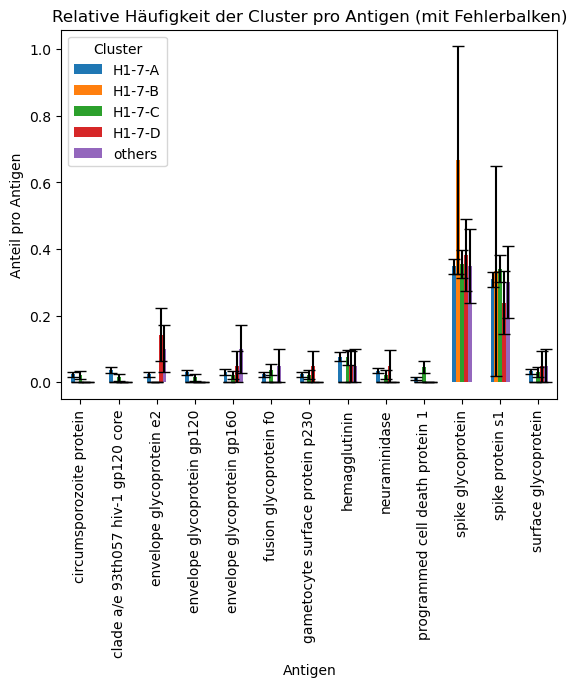

H1 - Länge 8:Chi² = 19.66, p = 0.0970, dof = 14


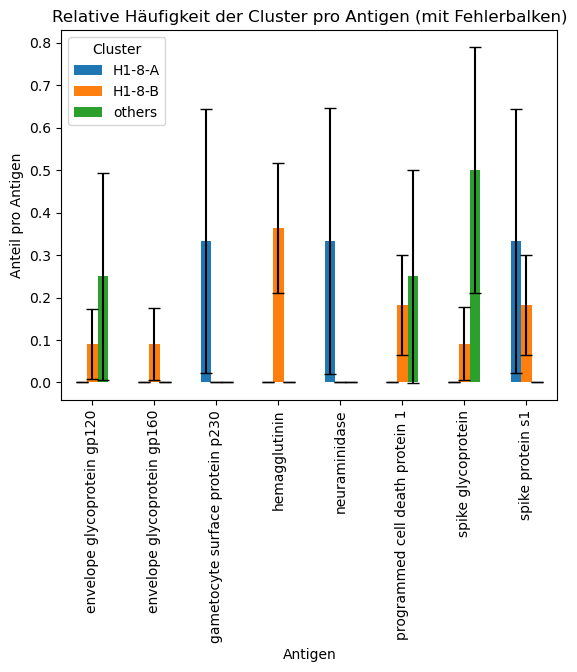

H1 - Länge 9:Chi² = 19.14, p = 0.1000, dof = 12


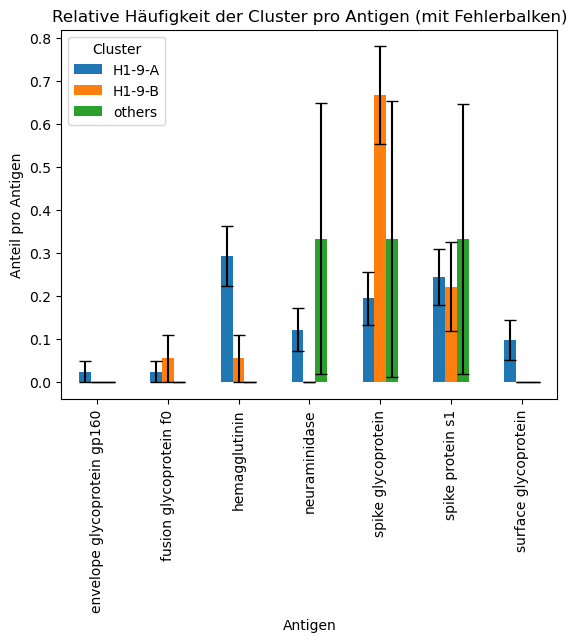

H2 - Länge 5:Chi² = 36.03, p = 0.1020, dof = 10


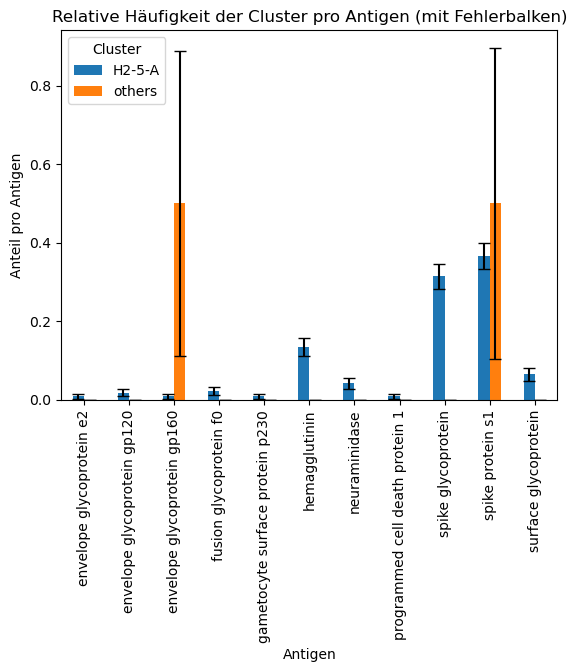

H2 - Länge 6:Chi² = 170.66, p < 0.0010, dof = 60


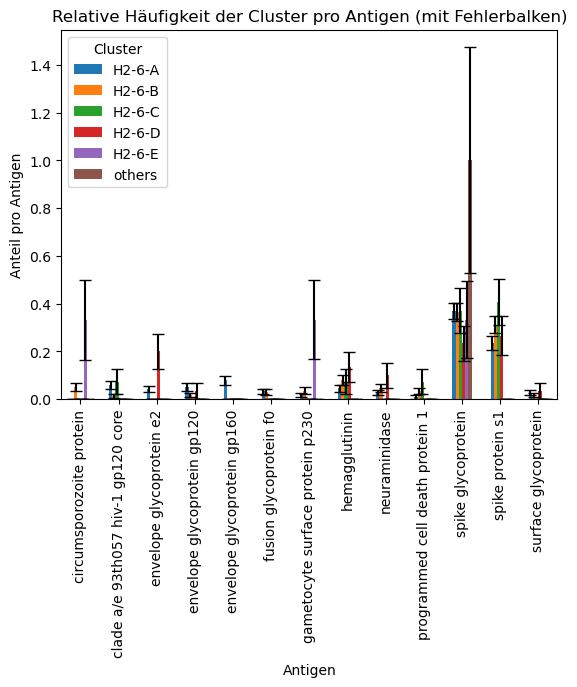

H2 - Länge 8:Chi² = 0.00, p = 1.0000, dof = 0


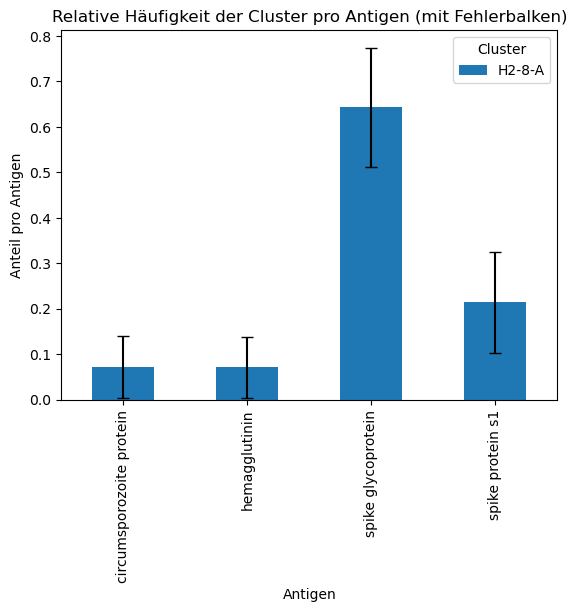

L1 - Länge 10:Chi² = 0.00, p = 1.0000, dof = 0


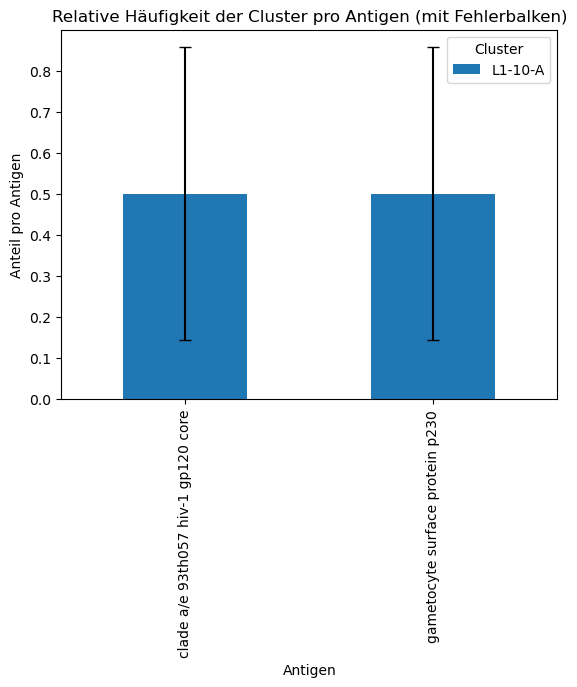

L1 - Länge 11:Chi² = 32.66, p = 0.0020, dof = 12


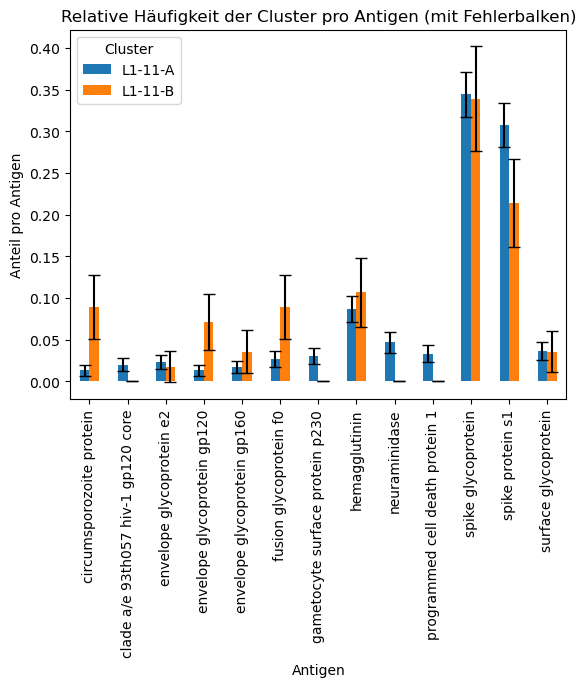

L1 - Länge 12:Chi² = 20.09, p = 0.4140, dof = 20


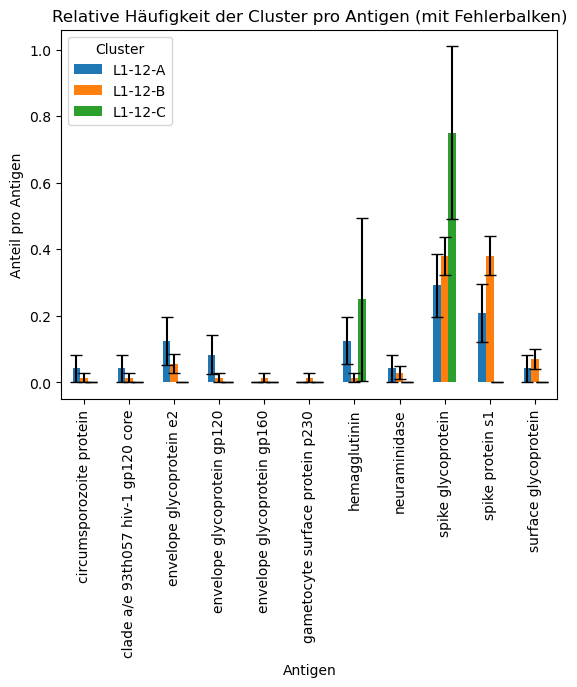

L1 - Länge 13:Chi² = 64.55, p = 0.0480, dof = 24


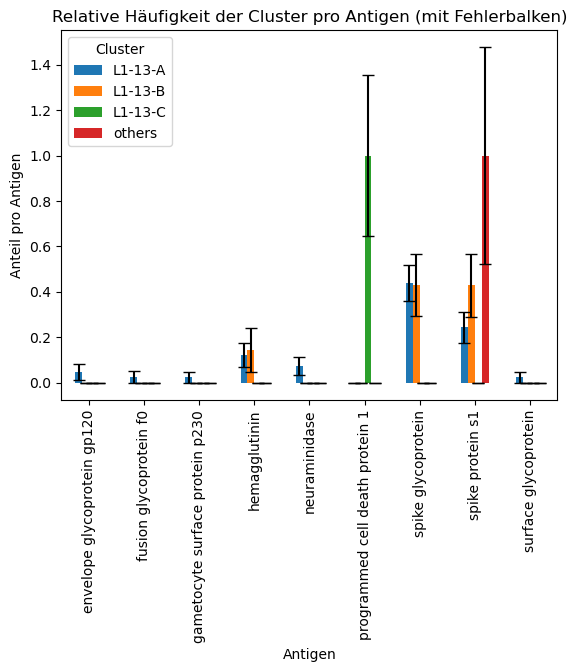

L1 - Länge 14:Chi² = 21.61, p = 0.4350, dof = 30


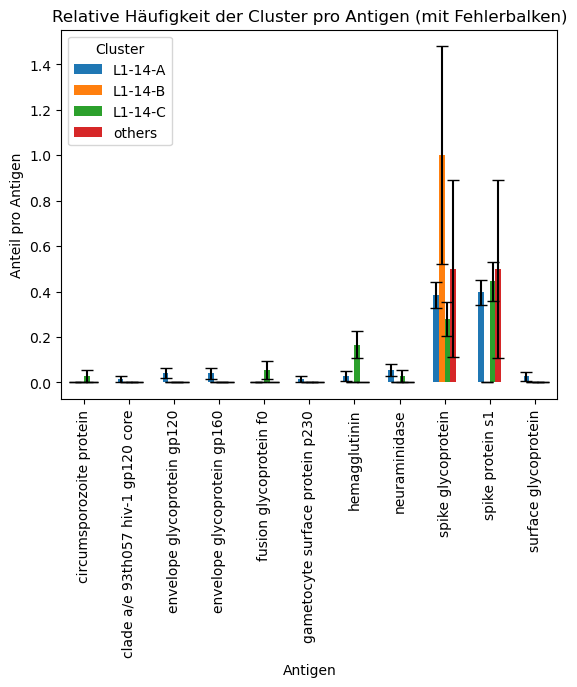

L1 - Länge 15:Chi² = 0.00, p = 1.0000, dof = 0


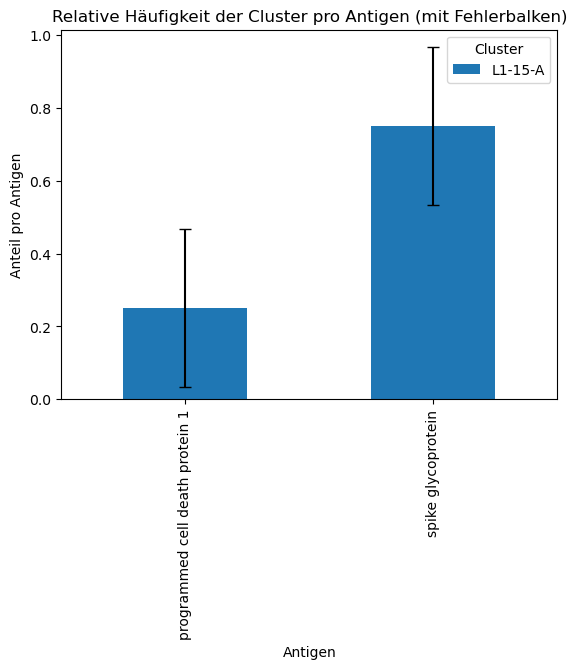

L1 - Länge 16:Chi² = 0.00, p = 1.0000, dof = 0


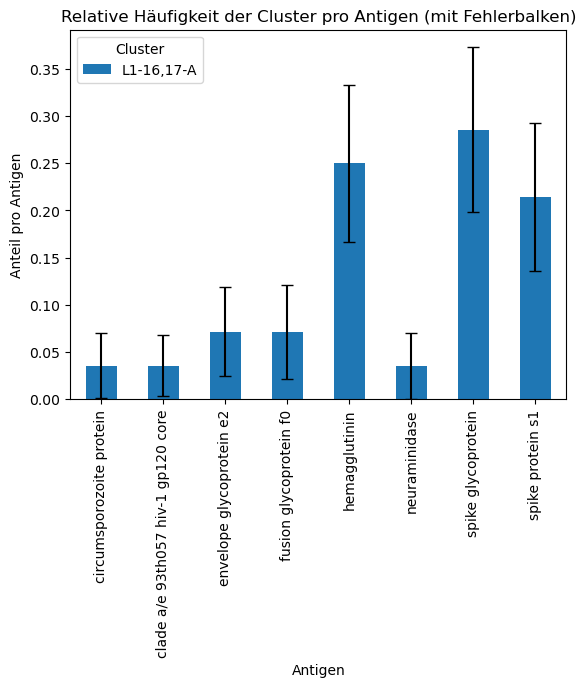

L1 - Länge 17:Chi² = 0.00, p = 1.0000, dof = 0


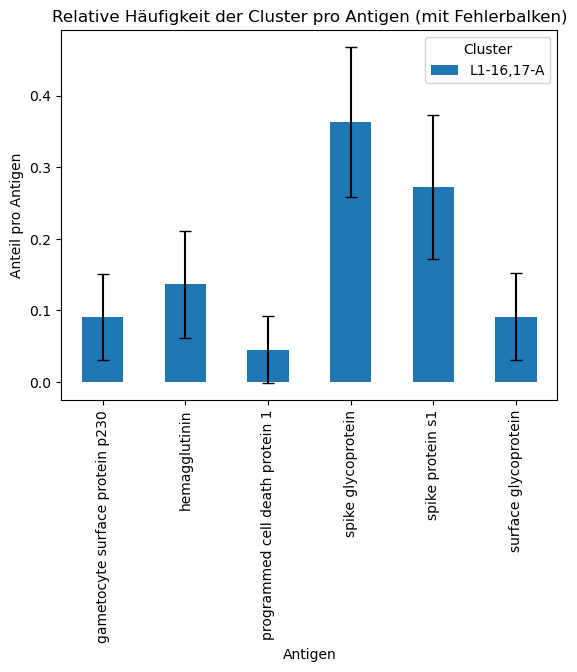

L2 - Länge 7:Chi² = 0.00, p = 1.0000, dof = 0


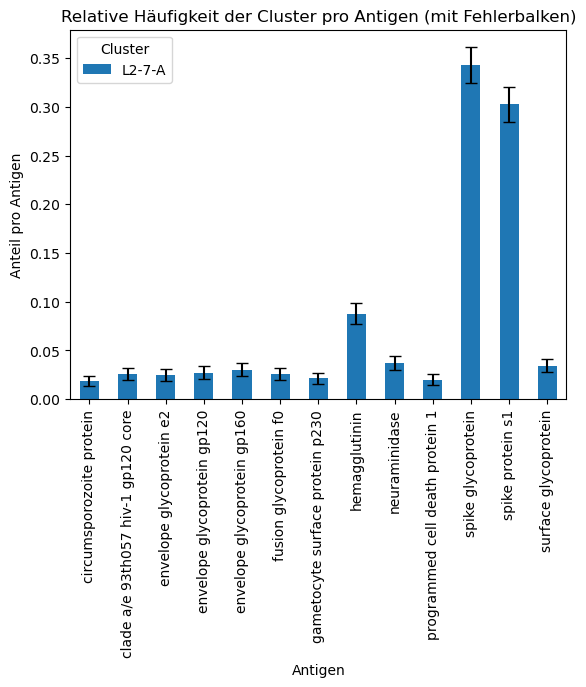

L3 - Länge 5:Chi² = 4.31, p = 0.3810, dof = 5


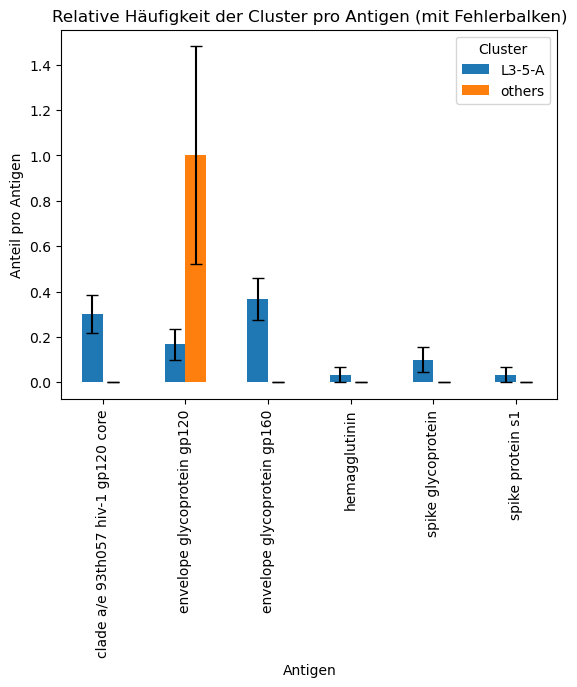

L3 - Länge 8:Chi² = 17.38, p = 0.1380, dof = 9


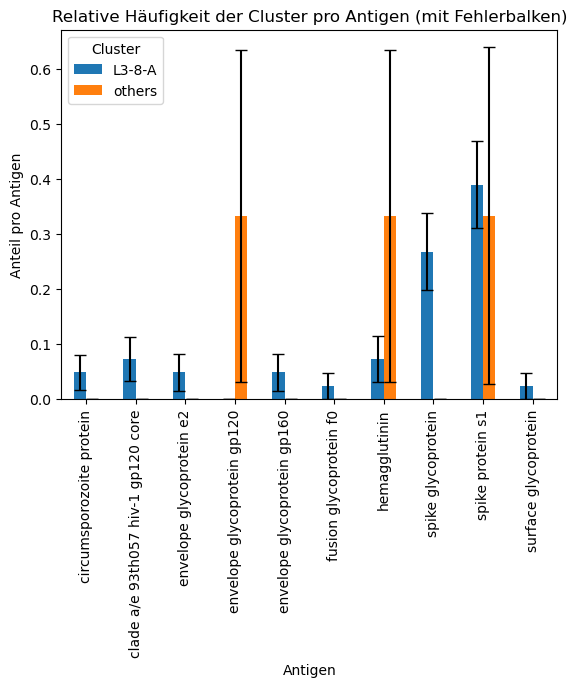

L3 - Länge 9:Chi² = 12.70, p = 0.3730, dof = 12


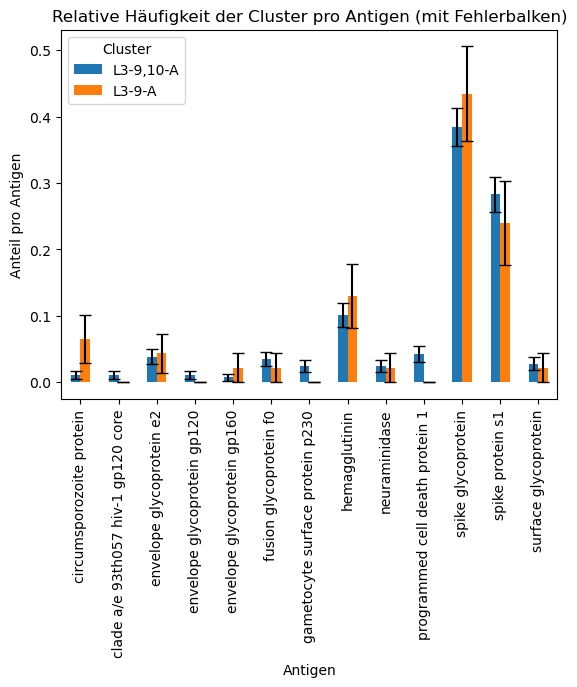

L3 - Länge 10:Chi² = 35.56, p = 0.2670, dof = 33


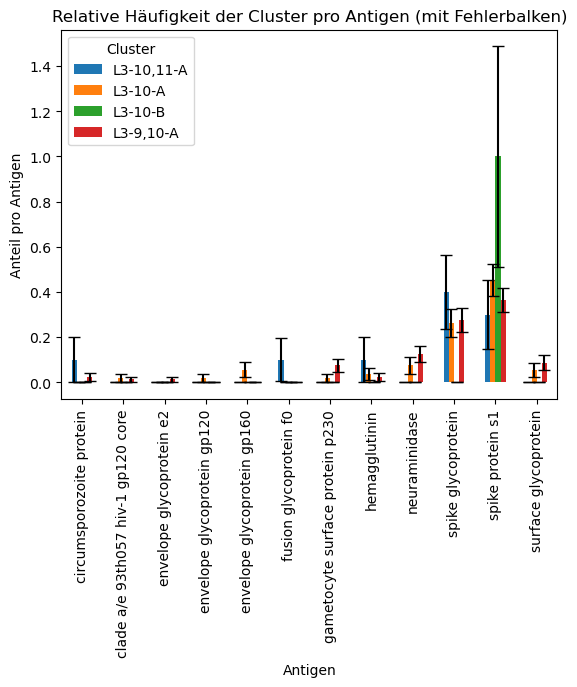

L3 - Länge 11:Chi² = 48.57, p = 0.0080, dof = 24


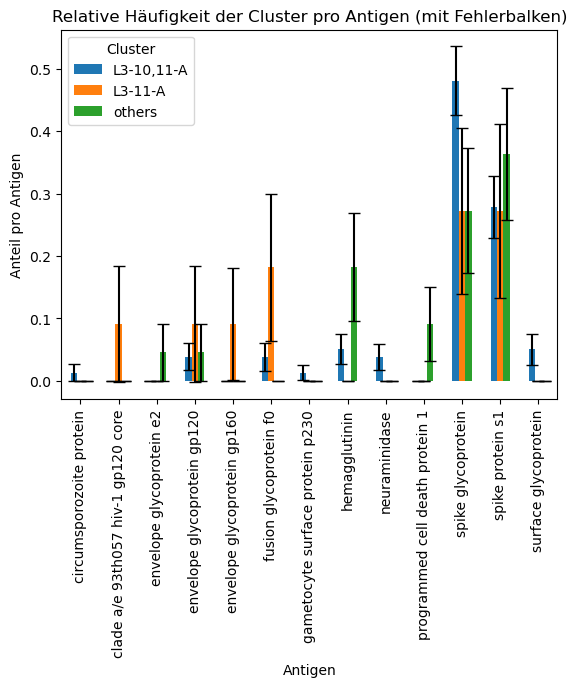

In [31]:
# Chi2-Permutationstest (Unabhängigkeitstest) für Vergleich der Cluster untereinander innerhalb derselben Längengruppen derselben CDR-Regionen

for region, cf_region in zip(regions, cf_regions):
    for len_group in regions_dict[region]:

        df = regions_dict[region][len_group]

        contingency = pd.crosstab(df[cf_region], df["antigen_name"])
        chi2_stat, p_value, dof, error_df = permutation_test(contingency, n_permutations = 1000, bootstrap_iterations = 1000)

        if p_value == 0:
            print(f"{region} - Länge {len_group}:Chi² = {chi2_stat:.2f}, p < {1/1000:.4f}, dof = {dof}")
        else:
            print(f"{region} - Länge {len_group}:Chi² = {chi2_stat:.2f}, p = {p_value:.4f}, dof = {dof}")
        #display(contingency)

        # Plot
        contingency_norm = normalize_contingency(contingency)
        contingency_norm.T.plot(
            kind='bar',
            stacked=False,
            yerr=error_df.T,
            capsize=4
        )
        
        plt.ylabel("Anteil pro Antigen")
        plt.xlabel("Antigen")
        plt.title("Relative Häufigkeit der Cluster pro Antigen (mit Fehlerbalken)")
        plt.legend(title="Cluster")
        plt.show()


In [32]:
'''# Chi2-Permutationstest (Unabhängigkeitstest)für Vergleich der Cluster untereiander innerhalb derselben CDR-Regionen (nicht getrennt nach Längengruppen)

for region, cf_region in zip(regions, cf_regions):
    
    df = pd.concat(regions_dict[region].values(), ignore_index=True)
    
    contingency = pd.crosstab(df[cf_region], df["antigen_name"])
    chi2_stat, p_value, dof = permutation_test(contingency, n_permutations = 1000)
    
    print(f"{region} - Gesamte Region: Chi² = {chi2_stat:.2f}, df = {dof}, p = {p_value:.4f}")
    display(contingency)'''

'# Chi2-Permutationstest (Unabhängigkeitstest)für Vergleich der Cluster untereiander innerhalb derselben CDR-Regionen (nicht getrennt nach Längengruppen)\n\nfor region, cf_region in zip(regions, cf_regions):\n    \n    df = pd.concat(regions_dict[region].values(), ignore_index=True)\n    \n    contingency = pd.crosstab(df[cf_region], df["antigen_name"])\n    chi2_stat, p_value, dof = permutation_test(contingency, n_permutations = 1000)\n    \n    print(f"{region} - Gesamte Region: Chi² = {chi2_stat:.2f}, df = {dof}, p = {p_value:.4f}")\n    display(contingency)'